In [1]:
import pandas as pd 

#df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Sociodemographics.csv')

df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/final_biogeme_Data_200.csv')

In [3]:
df_unique = df.drop_duplicates(subset='Response_ID')


In [5]:
df_unique

,Response_ID,Set_Assigned,Age_Middle_Age,Age_Old,Age_Young,Income_High,Income_Low,Income_Middle,Location_Large_City,Location_Medium_City,...,delta_delay,cost_zug_A,cost_zug_B,time_STR,time_BER,time_STR_BER,TripPurpose_Non_Time_Critical,TripPurpose_Time_Critical,Choice_ZugA,Choice_ZugB
0,28,2,0,1,0,0,1,0,1,0,...,1,30,45,2,0,2,0,1,1,0
10,30,1,0,0,1,0,0,1,1,0,...,0,30,45,2,0,2,1,0,1,0
20,31,3,1,0,0,1,0,0,1,0,...,0,30,45,2,0,2,1,0,1,0
30,37,2,0,0,1,0,1,0,1,0,...,1,30,45,2,0,2,0,1,0,1
40,44,1,0,0,1,0,1,0,1,0,...,0,30,45,2,0,2,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,568,4,0,0,1,0,0,1,0,0,...,0,30,45,2,0,2,1,0,1,0
1930,570,3,0,0,1,0,1,0,0,0,...,0,30,45,2,0,2,1,0,1,0
1940,571,1,1,0,0,0,0,1,0,0,...,0,30,45,2,0,2,1,0,1,0
1950,572,1,1,0,0,0,0,1,0,0,...,0,30,45,2,0,2,1,0,0,1


In [7]:
df.columns

Index(['Response_ID', 'Set_Assigned', 'Age_Middle_Age', 'Age_Old', 'Age_Young',
       'Income_High', 'Income_Low', 'Income_Middle', 'Location_Large_City',
       'Location_Medium_City', 'Location_Small_City', 'Education_University',
       'Education_Vocational_Non_Univ', 'Employment_Employed',
       'Employment_Not_Employed_Other', 'Employment_Student_Working',
       'PT_Intercity_freq_Frequent_User', 'PT_Intercity_freq_Non_User',
       'PT_Intercity_freq_Occasional_User', 'PT_Intercity_freq_Rare_User',
       'PT_Freq_TC_Frequent', 'PT_Freq_TC_Infrequent', 'PT_Freq_TC_Occasional',
       'PT_Freq_NTC_Frequent', 'PT_Freq_NTC_Infrequent',
       'PT_Freq_NTC_Occasional', 'PT_DB_IC_Frequent', 'PT_DB_IC_Infrequent',
       'PT_DB_IC_Occasional', 'PT_DB_Rb_Frequent', 'PT_DB_Rb_Infrequent',
       'PT_DB_Rb_Occasional', 'Coach_Frequent', 'Coach_Infrequent',
       'Coach_Occasional', 'BlaBla_Frequent', 'BlaBla_Infrequent',
       'BlaBla_Occasional', 'HiredCar_Infrequent', 'HiredCar_Oc

In [9]:
[
    "PT_Freq_NTC_Occasional", "PT_DB_IC_Frequent", "PT_DB_IC_Infrequent", "PT_DB_IC_Occasional", 
    "PT_DB_Rb_Frequent", "PT_DB_Rb_Infrequent", "PT_DB_Rb_Occasional", "Coach_Frequent", "Coach_Infrequent", 
    "Coach_Occasional", "BlaBla_Frequent", "BlaBla_Infrequent", "BlaBla_Occasional", "HiredCar_Infrequent", 
    "HiredCar_Occasional", "PrivateCar_Frequent", "PrivateCar_Infrequent", "PrivateCar_Occasional", 
    
]


['PT_Freq_NTC_Occasional',
 'PT_DB_IC_Frequent',
 'PT_DB_IC_Infrequent',
 'PT_DB_IC_Occasional',
 'PT_DB_Rb_Frequent',
 'PT_DB_Rb_Infrequent',
 'PT_DB_Rb_Occasional',
 'Coach_Frequent',
 'Coach_Infrequent',
 'Coach_Occasional',
 'BlaBla_Frequent',
 'BlaBla_Infrequent',
 'BlaBla_Occasional',
 'HiredCar_Infrequent',
 'HiredCar_Occasional',
 'PrivateCar_Frequent',
 'PrivateCar_Infrequent',
 'PrivateCar_Occasional']

In [11]:
import pandas as pd

# Deduplicate by Response_ID if needed
df_unique = df.drop_duplicates(subset='Response_ID')

# Calculate number of users who said Yes to Car License
car_license_yes = df_unique[df_unique['Car_License_Yes'] == 1]

# Total count of users with Car License = Yes
n_car_license_yes = len(car_license_yes)

# Calculate counts of Car Possession Yes/No within Car License = Yes group
car_poss_yes_count = car_license_yes['Car_Yes'].sum()
car_poss_no_count = car_license_yes['Car_No'].sum()

# Calculate conditional percentages for Car Possession
car_poss_yes_pct = 100 * car_poss_yes_count / n_car_license_yes
car_poss_no_pct = 100 * car_poss_no_count / n_car_license_yes

print(f"Car Possession Yes (conditional %): {car_poss_yes_pct:.2f}")
print(f"Car Possession No (conditional %): {car_poss_no_pct:.2f}")


Car Possession Yes (conditional %): 70.71
Car Possession No (conditional %): 29.29


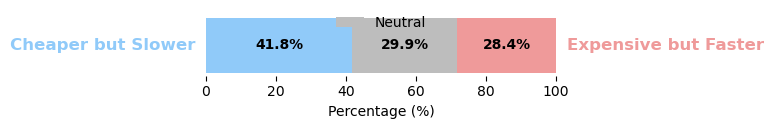

In [13]:
import matplotlib.pyplot as plt

# Data for single comparison
labels = ("Cheaper but Slower", "Expensive but Faster")
values = [41.8, 29.9, 28.4]  # [left, neutral, right]
colors = ["#90caf9", "#bdbdbd", "#ef9a9a"]

fig, ax = plt.subplots(figsize=(8, 1.5))

# Draw left, neutral, right bar segments sequentially
ax.barh(0, values[0], color=colors[0])
ax.barh(0, values[1], left=values[0], color=colors[1])
ax.barh(0, values[2], left=values[0] + values[1], color=colors[2])

# Annotate labels just outside the two ends
ax.text(-3, 0, labels[0], va='center', ha='right', color=colors[0], fontsize=12, weight='bold')
ax.text(103, 0, labels[1], va='center', ha='left', color=colors[2], fontsize=12, weight='bold')

# Add percentage text annotations in the center of each bar segment
ax.text(values[0] / 2, 0, f"{values[0]:.1f}%", va='center', ha='center', color='black', fontsize=10, weight='bold')
ax.text(values[0] + values[1] / 2, 0, f"{values[1]:.1f}%", va='center', ha='center', color='black', fontsize=10, weight='bold')
ax.text(values[0] + values[1] + values[2] / 2, 0, f"{values[2]:.1f}%", va='center', ha='center', color='black', fontsize=10, weight='bold')

# Remove y-axis ticks and set limits
ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage (%)")
ax.set_frame_on(False)
ax.set_yticklabels([])

# Optional: Show legend only for Neutral if desired
from matplotlib.patches import Patch
custom_handles = [Patch(facecolor=colors[1], label="Neutral")]
ax.legend(handles=custom_handles, loc="upper center", bbox_to_anchor=(0.5, 1.2), frameon=False)

plt.tight_layout()
plt.savefig("/Users/syed/Downloads/Applications/Companies/Thesis/Coding/comparison_bars.png", dpi=300, bbox_inches='tight')
plt.show()


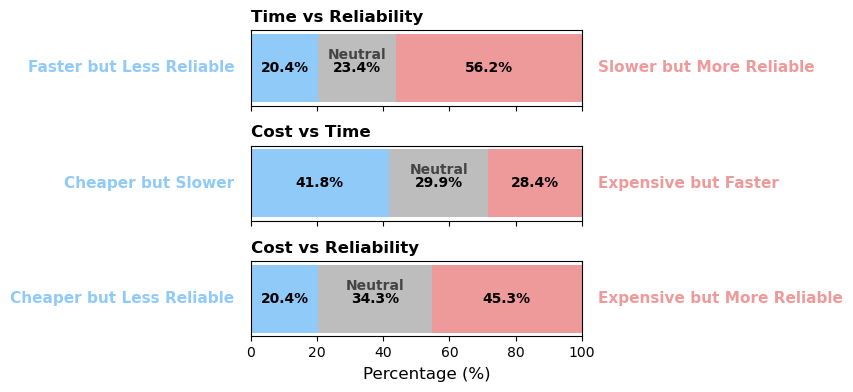

In [79]:
import matplotlib.pyplot as plt

# Data for three comparisons:
comparisons = {
    "Time vs Reliability": [20.40, 23.38, 56.22],         # Left, Neutral, Right
    "Cost vs Time": [41.8, 29.9, 28.4],               # Left, Neutral, Right
    "Cost vs Reliability": [20.4, 34.3, 45.3]         # Left, Neutral, Right
}

labels = {
    "Time vs Reliability": ["Faster but Less Reliable", "Neutral", "Slower but More Reliable"],
    "Cost vs Time": ["Cheaper but Slower", "Neutral", "Expensive but Faster"],
    "Cost vs Reliability": ["Cheaper but Less Reliable", "Neutral", "Expensive but More Reliable"]
}

colors = ["#90caf9", "#bdbdbd", "#ef9a9a"]  # blue, gray (neutral), red

fig, axes = plt.subplots(len(comparisons), 1, figsize=(9, 4), sharex=True)

for ax, (comp, values) in zip(axes, comparisons.items()):
    left = 0
    for i, value in enumerate(values):
        ax.barh(0, value, left=left, color=colors[i], edgecolor='none')
        # Annotate percentages centered
        ax.text(left + value / 2, 0, f"{value:.1f}%", va='center', ha='center', fontsize=10, weight='bold', color='black')
        # Add Neutral label inside gray bar, slightly above center
        if i == 1:
            ax.text(left + value / 2, 0.15, "Neutral", va='center', ha='center', fontsize=10, weight='bold', color='#444444')
        left += value
    # Left and right labels on sides but inside figure area
    ax.text(-5, 0, labels[comp][0], va='center', ha='right', fontsize=11, weight='bold', color=colors[0])
    ax.text(105, 0, labels[comp][2], va='center', ha='left', fontsize=11, weight='bold', color=colors[2])

    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_title(comp, fontsize=12, fontweight='bold', loc='left')

fig.text(0.5, 0.04, 'Percentage (%)', ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("/Users/syed/Downloads/Applications/Companies/Thesis/Coding/3comparison_bars.png", dpi=300, bbox_inches='tight')
plt.show()


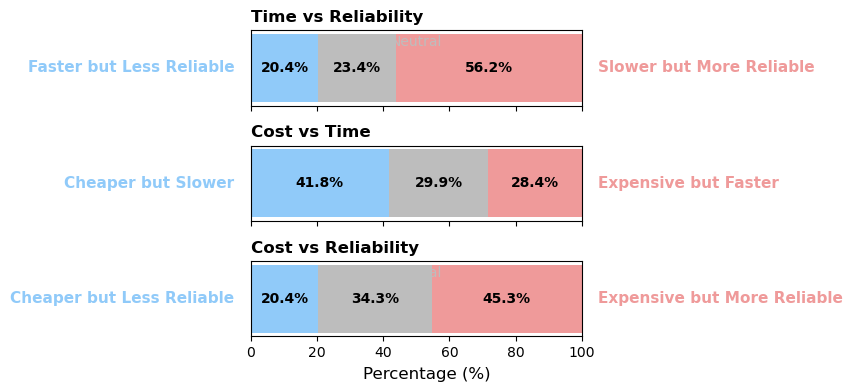

In [77]:
import matplotlib.pyplot as plt

# Data for three comparisons:
comparisons = {
    "Time vs Reliability": [20.40, 23.38, 56.22],         # Low, Medium, High
    "Cost vs Time": [41.8, 29.9, 28.4],               # Cheaper but Slower, Neutral, Expensive but Faster
    "Cost vs Reliability": [20.4, 34.3, 45.3]         # Cheaper but Less Reliable, Neutral, Expensive but More Reliable
}

labels = {
    "Time vs Reliability": ["Faster but Less Reliable", "Neutral", "Slower but More Reliable"],
    "Cost vs Time": ["Cheaper but Slower", "Neutral", "Expensive but Faster"],
    "Cost vs Reliability": ["Cheaper but Less Reliable", "Neutral", "Expensive but More Reliable"]
}

colors = ["#90caf9", "#bdbdbd", "#ef9a9a"]  # blue, gray (neutral), red

fig, axes = plt.subplots(len(comparisons), 1, figsize=(9, 4), sharex=True)

for ax, (comp, values) in zip(axes, comparisons.items()):
    left = 0
    for i, value in enumerate(values):
        ax.barh(0, value, left=left, color=colors[i], edgecolor='none')
        # Annotate percentages centered
        ax.text(left + value / 2, 0, f"{value:.1f}%", va='center', ha='center', fontsize=10, weight='bold', color='black')
        left += value
    # Left and right labels on sides but inside figure area
    ax.text(-5, 0, labels[comp][0], va='center', ha='right', fontsize=11, weight='bold', color=colors[0])
    ax.text(105, 0, labels[comp][2], va='center', ha='left', fontsize=11, weight='bold', color=colors[2])
    # Middle label centered above bar
    ax.text(50, 0.3, "Neutral", va='center', ha='center', fontsize=10, color=colors[1])

    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_title(comp, fontsize=12, fontweight='bold', loc='left')

fig.text(0.5, 0.04, 'Percentage (%)', ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

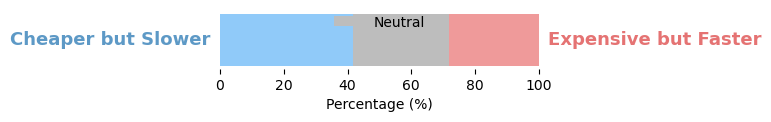

In [17]:
import matplotlib.pyplot as plt

# Data and labels for the one comparison
left, neutral, right = 41.8, 29.9, 28.4
labels = ("Cheaper but Slower", "Expensive but Faster")
colors = ["#90caf9", "#bdbdbd", "#ef9a9a"]

fig, ax = plt.subplots(figsize=(8, 1.4))

# Draw the segments
ax.barh(0, left, color=colors[0])
ax.barh(0, neutral, left=left, color=colors[1])
ax.barh(0, right, left=left+neutral, color=colors[2])

# Labels on the ends (smaller, bolder, darker)
ax.text(-3, 0, labels[0], va='center', ha='right', color="#5d99c6", fontsize=13, weight='bold')
ax.text(103, 0, labels[1], va='center', ha='left', color="#e57373", fontsize=13, weight='bold')

# No bar labels for neutral
ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage (%)")
ax.set_frame_on(False)
ax.set_yticklabels([])
ax.tick_params(left=False, labelleft=False)

# Simple legend (Neutral only if you wish)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=colors[1], label="Neutral")], loc="upper center", bbox_to_anchor=(0.5, 1.15), frameon=False)

plt.tight_layout()
plt.savefig("/Users/syed/Downloads/Applications/Companies/Thesis/Coding/comparison_bars.png", dpi=300, bbox_inches='tight')
plt.show()


In [67]:
import pandas as pd

# Assuming df is your dataframe already loaded and cleaned
if "Response_ID" in df.columns:
    df = df.drop_duplicates(subset="Response_ID")
n_total = len(df)

# Define structure as: (Attribute, [(Category, ColumnName, IndentLevel)])
structure = [
    ("Age Category", [("Young", "Age_Young", 0), ("Middle Age", "Age_Middle_Age", 0), ("Old", "Age_Old", 0)]),
    ("Income Category", [("Low", "Income_Low", 0), ("Middle", "Income_Middle", 0), ("High", "Income_High", 0)]),
    ("Gender", [("Male", "Gender_Male", 0), ("Female", "Gender_Female", 0), ("Other", "Gender_Other", 0), ("No Answer", "Gender_No_Answer", 0)]),
    ("Education", [("University", "Education_University", 0), ("Vocational Non-Univ", "Education_Vocational_Non_Univ", 0)]),
    ("Employment", [("Employed", "Employment_Employed", 0), ("Student (& Working)", "Employment_Student_Working", 0), ("Not Employed", "Employment_Not_Employed_Other", 0)]),
    ("Location", [("Large City", "Location_Large_City", 0), ("Medium City", "Location_Medium_City", 0), ("Small City", "Location_Small_City", 0)]),
    ("Car License", [("Yes", "Car_License_Yes", 0), ("No", "Car_License_No", 0)]),
    ("Car Possession", [("Yes", "Car_Yes", 1), ("No", "Car_No", 1)]),
]

# Calculate car possession only among those with car license "Yes"
n_car_license_yes = int(df["Car_License_Yes"].sum())
poss_output = []
for label, col, indent in structure[-1][1]:
    if n_car_license_yes > 0:
        count = df[(df["Car_License_Yes"] == 1) & (df[col] == 1)].shape[0]
        pct = 100 * count / n_car_license_yes
    else:
        count, pct = 0, 0
    poss_output.append((label, count, round(pct, 1), indent))

latex_rows = []
for attr, items in structure[:-1]:
    for i, (label, col, indent) in enumerate(items):
        count = int(df[col].sum())
        pct = round(100 * count / n_total, 1) if n_total else 0
        indent_text = "\\hspace{2em}" if indent else ""
        if i == 0:
            latex_rows.append(f"\\multirow{{{len(items)}}}{{*}}{{{attr}}} & {indent_text}{label} & {pct} \\\\")
        else:
            latex_rows.append(f" & {indent_text}{label} & {pct} \\\\")
    latex_rows.append("\\cmidrule(lr){2-3}")

# Insert car possession rows under 'Yes' of Car License
final_latex_lines = []
inserted = False
for line in latex_rows:
    final_latex_lines.append(line)
    if not inserted and line.strip().endswith("Car License}} & Yes"):
        inserted = True
        for label, count, pct, indent in poss_output:
            final_latex_lines.append(f" & \\hspace{{2em}}{label} & {pct} \\\\")

# Print out formatted LaTeX table code
print("\\begin{table}[ht]")
print("\\centering")
print("\\setlength{\\tabcolsep}{6pt}")
print("\\renewcommand{\\arraystretch}{1.2}")
print("\\begin{tabular}{@{} >{\\raggedright\\arraybackslash}p{2.5cm} >{\\raggedright\\arraybackslash}p{4.5cm} r @{} }")
print("\\toprule")
print("\\textbf{Attribute} & \\textbf{Category} & \\textbf{Percentage (\\%)} \\\\")
print("\\midrule")
for row in final_latex_lines:
    print(row)
print("\\bottomrule")
print("\\end{tabular}")
print("\\caption{Descriptive Statistics of the Sociodemographics}")
print("\\label{tab:sociodemographics}")
print("\\end{table}")


\begin{table}[ht]
\centering
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{@{} >{\raggedright\arraybackslash}p{2.5cm} >{\raggedright\arraybackslash}p{4.5cm} r @{} }
\toprule
\textbf{Attribute} & \textbf{Category} & \textbf{Percentage (\%)} \\
\midrule
\multirow{3}{*}{Age Category} & Young & 62.9 \\
 & Middle Age & 26.4 \\
 & Old & 9.6 \\
\cmidrule(lr){2-3}
\multirow{3}{*}{Income Category} & Low & 48.2 \\
 & Middle & 34.5 \\
 & High & 10.2 \\
\cmidrule(lr){2-3}
\multirow{4}{*}{Gender} & Male & 48.2 \\
 & Female & 47.7 \\
 & Other & 1.0 \\
 & No Answer & 3.0 \\
\cmidrule(lr){2-3}
\multirow{2}{*}{Education} & University & 74.1 \\
 & Vocational Non-Univ & 22.8 \\
\cmidrule(lr){2-3}
\multirow{3}{*}{Employment} & Employed & 56.9 \\
 & Student (& Working) & 34.5 \\
 & Not Employed & 4.6 \\
\cmidrule(lr){2-3}
\multirow{3}{*}{Location} & Large City & 65.5 \\
 & Medium City & 12.7 \\
 & Small City & 21.8 \\
\cmidrule(lr){2-3}
\multirow{2}{*}{Car License} & Yes & 5

In [71]:
import pandas as pd

# Deduplicate respondents if necessary
if "Response_ID" in df.columns:
    df = df.drop_duplicates(subset="Response_ID")
n_total = len(df)

# Define attribute structure (Attribute, (Category, ColumnName, IndentLevel))
structure = [
    ("Age Category", [("Young", "Age_Young", 0), ("Middle Age", "Age_Middle_Age", 0), ("Old", "Age_Old", 0)]),
    ("Income Category", [("Low", "Income_Low", 0), ("Middle", "Income_Middle", 0), ("High", "Income_High", 0)]),
    ("Gender", [("Male", "Gender_Male", 0), ("Female", "Gender_Female", 0), ("Other", "Gender_Other", 0), ("No Answer", "Gender_No_Answer", 0)]),
    ("Education", [("University", "Education_University", 0), ("Vocational Non-Univ", "Education_Vocational_Non_Univ", 0)]),
    ("Employment", [("Employed", "Employment_Employed", 0), ("Student (& Working)", "Employment_Student_Working", 0), ("Not Employed", "Employment_Not_Employed_Other", 0)]),
    ("Location", [("Large City", "Location_Large_City", 0), ("Medium City", "Location_Medium_City", 0), ("Small City", "Location_Small_City", 0)]),
    ("Car License", [("Yes", "Car_License_Yes", 0), ("No", "Car_License_No", 0)]),
    ("Car Possession", [("Yes", "Car_Yes", 1), ("No", "Car_No", 1)]),
]

# Calculate number of respondents with Car License Yes
n_car_license_yes = int(df["Car_License_Yes"].sum())

# Car Possession counts and percentages conditional on having car license
poss_output = []
for label, col, indent in structure[-1][1]:
    if n_car_license_yes > 0:
        count = df[(df["Car_License_Yes"] == 1) & (df[col] == 1)].shape[0]
        pct = 100 * count / n_car_license_yes
    else:
        count, pct = 0, 0
    poss_output.append((label, count, round(pct, 1), indent))

# Build LaTeX code for all attributes except Car Possession
latex = []
for attr, items in structure[:-1]:
    for i, (label, col, indent) in enumerate(items):
        count = int(df[col].sum())
        pct = round(100 * count / n_total, 1) if n_total else 0
        indent_str = "\\hspace{2em}" if indent else ""
        if i == 0:
            latex.append(f"\\multirow{{{len(items)}}}{{*}}{{{attr}}} & {indent_str}{label} & {count} & {pct} \\\\")
        else:
            latex.append(f" & {indent_str}{label} & {count} & {pct} \\\\")
    latex.append("\\cmidrule(lr){2-4}")

# Insert Car Possession rows immediately after Car License's 'Yes' row
latex_with_possession = []
inserted = False
for line in latex:
    latex_with_possession.append(line)
    if not inserted and line.strip().endswith("Car License}} & Yes"):
        inserted = True
        for label, count, pct, indent in poss_output:
            latex_with_possession.append(f" & \\hspace{{2em}}{label} & {count} & {pct} \\\\")

# Print final LaTeX tabular environment ready code
print("\\begin{tabular}{@{} >{\\raggedright\\arraybackslash}p{2.5cm} >{\\raggedright\\arraybackslash}p{4.5cm} r r @{} }")
print("\\toprule")
print("\\textbf{Attribute} & \\textbf{Category} & \\textbf{Count} & \\textbf{Percentage} \\\\")
print("\\midrule")
for row in latex_with_possession:
    print(row)
print("\\bottomrule")
print("\\end{tabular}")


\begin{tabular}{@{} >{\raggedright\arraybackslash}p{2.5cm} >{\raggedright\arraybackslash}p{4.5cm} r r @{} }
\toprule
\textbf{Attribute} & \textbf{Category} & \textbf{Count} & \textbf{Percentage} \\
\midrule
\multirow{3}{*}{Age Category} & Young & 124 & 62.9 \\
 & Middle Age & 52 & 26.4 \\
 & Old & 19 & 9.6 \\
\cmidrule(lr){2-4}
\multirow{3}{*}{Income Category} & Low & 95 & 48.2 \\
 & Middle & 68 & 34.5 \\
 & High & 20 & 10.2 \\
\cmidrule(lr){2-4}
\multirow{4}{*}{Gender} & Male & 95 & 48.2 \\
 & Female & 94 & 47.7 \\
 & Other & 2 & 1.0 \\
 & No Answer & 6 & 3.0 \\
\cmidrule(lr){2-4}
\multirow{2}{*}{Education} & University & 146 & 74.1 \\
 & Vocational Non-Univ & 45 & 22.8 \\
\cmidrule(lr){2-4}
\multirow{3}{*}{Employment} & Employed & 112 & 56.9 \\
 & Student (& Working) & 68 & 34.5 \\
 & Not Employed & 9 & 4.6 \\
\cmidrule(lr){2-4}
\multirow{3}{*}{Location} & Large City & 129 & 65.5 \\
 & Medium City & 25 & 12.7 \\
 & Small City & 43 & 21.8 \\
\cmidrule(lr){2-4}
\multirow{2}{*}{Car Lice

In [21]:
import pandas as pd

# Load data and deduplicate as needed
if "Response_ID" in df.columns:
    df = df.drop_duplicates(subset="Response_ID")
n_total = len(df)

# Attribute -> (Category, Column Name, Indent Level)
structure = [
    ("Age Category", [("Young", "Age_Young", 0), ("Middle Age", "Age_Middle_Age", 0), ("Old", "Age_Old", 0)]),
    ("Income Category", [("Low", "Income_Low", 0), ("Middle", "Income_Middle", 0), ("High", "Income_High", 0)]),
    ("Gender", [("Male", "Gender_Male", 0), ("Female", "Gender_Female", 0), ("Other", "Gender_Other", 0), ("No Answer", "Gender_No_Answer", 0)]),
    ("Education", [("University", "Education_University", 0), ("Vocational Non-Univ", "Education_Vocational_Non_Univ", 0)]),
    ("Employment", [("Employed", "Employment_Employed", 0), ("Student (& Working)", "Employment_Student_Working", 0), ("Not Employed", "Employment_Not_Employed_Other", 0)]),
    ("Location", [("Large City", "Location_Large_City", 0), ("Medium City", "Location_Medium_City", 0), ("Small City", "Location_Small_City", 0)]),
    # Car License with nested Possession
    ("Car License", [("Yes", "Car_License_Yes", 0), ("No", "Car_License_No", 0)]),
    ("Car Possession", [("Yes", "Car_Yes", 1), ("No", "Car_No", 1)]),
]

# We'll calculate car possession only among those with 'Car License' == Yes:
n_car_license_yes = int(df["Car_License_Yes"].sum())
poss_output = []
for label, col, indent in structure[-1][1]:
    if n_car_license_yes > 0:
        count = df[(df["Car_License_Yes"] == 1) & (df[col] == 1)].shape[0]
        pct = 100 * count / n_car_license_yes
    else:
        count, pct = 0, 0
    poss_output.append((label, count, round(pct, 1), indent))

latex = []
for attr, items in structure[:-1]:
    for i, (label, col, indent) in enumerate(items):
        count = int(df[col].sum())
        pct = round(100 * count / n_total, 1) if n_total else 0
        indent_txt = f"\\hspace{{2em}}" if indent else ""
        if i == 0:
            latex.append(f"\\multirow{{{len(items)}}}{{*}}{{{attr}}} & {indent_txt}{label} & {count} & {pct} \\\\")
        else:
            latex.append(f" & {indent_txt}{label} & {count} & {pct} \\\\")
    latex.append("\\cmidrule(lr){2-4}")

# Insert Car Possession as nested row under 'Yes' of Car License
latex.insert(
    latex.index("\\cmidrule(lr){2-4}"),
    ""
)
latex_with_possession = []
for line in latex:
    if line.strip().endswith("Car License}} & Yes"):
        latex_with_possession.append(line)
        for label, count, pct, indent in poss_output:
            latex_with_possession.append(f" & \\hspace{{2em}}{label} & {count} & {pct} \\\\")
    else:
        latex_with_possession.append(line)

# Print formatted LaTeX table (ready to copy-paste!)
print("\\begin{tabular}{@{} >{\\raggedright\\arraybackslash}p{2.5cm} >{\\raggedright\\arraybackslash}p{4.5cm} r r @{} }")
print("\\toprule")
print("\\textbf{Attribute} & \\textbf{Category} & \\textbf{Count} & \\textbf{Percentage} \\\\")
print("\\midrule")
for line in latex_with_possession:
    print(line)
print("\\bottomrule")
print("\\end{tabular}")


\begin{tabular}{@{} >{\raggedright\arraybackslash}p{2.5cm} >{\raggedright\arraybackslash}p{4.5cm} r r @{} }
\toprule
\textbf{Attribute} & \textbf{Category} & \textbf{Count} & \textbf{Percentage} \\
\midrule
\multirow{3}{*}{Age Category} & Young & 124 & 62.9 \\
 & Middle Age & 52 & 26.4 \\
 & Old & 19 & 9.6 \\

\cmidrule(lr){2-4}
\multirow{3}{*}{Income Category} & Low & 95 & 48.2 \\
 & Middle & 68 & 34.5 \\
 & High & 20 & 10.2 \\
\cmidrule(lr){2-4}
\multirow{4}{*}{Gender} & Male & 95 & 48.2 \\
 & Female & 94 & 47.7 \\
 & Other & 2 & 1.0 \\
 & No Answer & 6 & 3.0 \\
\cmidrule(lr){2-4}
\multirow{2}{*}{Education} & University & 146 & 74.1 \\
 & Vocational Non-Univ & 45 & 22.8 \\
\cmidrule(lr){2-4}
\multirow{3}{*}{Employment} & Employed & 112 & 56.9 \\
 & Student (& Working) & 68 & 34.5 \\
 & Not Employed & 9 & 4.6 \\
\cmidrule(lr){2-4}
\multirow{3}{*}{Location} & Large City & 129 & 65.5 \\
 & Medium City & 25 & 12.7 \\
 & Small City & 43 & 21.8 \\
\cmidrule(lr){2-4}
\multirow{2}{*}{Car Lic

In [25]:
for attr, items in structure[:-1]:
    cols = [col for _, col, _ in items]
    sum_per_row = df[cols].sum(axis=1)
    print(f"{attr}: counts where a respondent matches more than one category: {(sum_per_row > 1).sum()}")
    print(f"{attr}: counts where a respondent matches zero category: {(sum_per_row == 0).sum()}")

for attr, items in structure[:-1]:
    cols = [col for _, col, _ in items]
    # Count for attribute: valid rows where sum in those columns == 1
    valid = df[cols].sum(axis=1) == 1
    N_valid = valid.sum()
    # Calculate count and percent per category only among valid
    for i, (label, col, indent) in enumerate(items):
        count = (df[cols][col][valid] == 1).sum()
        pct = 100 * count / N_valid if N_valid else 0
        ...



Age Category: counts where a respondent matches more than one category: 0
Age Category: counts where a respondent matches zero category: 2
Income Category: counts where a respondent matches more than one category: 0
Income Category: counts where a respondent matches zero category: 14
Gender: counts where a respondent matches more than one category: 0
Gender: counts where a respondent matches zero category: 0
Education: counts where a respondent matches more than one category: 0
Education: counts where a respondent matches zero category: 6
Employment: counts where a respondent matches more than one category: 0
Employment: counts where a respondent matches zero category: 8
Location: counts where a respondent matches more than one category: 0
Location: counts where a respondent matches zero category: 0
Car License: counts where a respondent matches more than one category: 0
Car License: counts where a respondent matches zero category: 0


In [73]:
# --- Compute car license and car possession values ---
car_license_yes_pct = round(100 * df["Car_License_Yes"].sum() / n_total, 1)
car_license_no_pct = round(100 * df["Car_License_No"].sum() / n_total, 1)
n_car_license_yes = int(df["Car_License_Yes"].sum())

if n_car_license_yes > 0:
    car_poss_yes = df[(df["Car_License_Yes"] == 1) & (df["Car_Yes"] == 1)].shape[0]
    car_poss_no  = df[(df["Car_License_Yes"] == 1) & (df["Car_No"] == 1)].shape[0]
    car_poss_yes_pct = round(100 * car_poss_yes / n_car_license_yes, 1)
    car_poss_no_pct  = round(100 * car_poss_no  / n_car_license_yes, 1)
else:
    car_poss_yes, car_poss_no, car_poss_yes_pct, car_poss_no_pct = 0, 0, 0, 0

# --- Insert the block, preserving TikZ formatting ---
print("\\multirow{4}{*}{Car License} & ")
print("\\begin{tikzpicture}[baseline=(A.base),every node/.style={anchor=base}]")
print("\\node (A) {Yes};")
print("\\draw[] (A.south) -- ++(0,-5mm) -| ++(2.5mm,-0mm) node[right] {Car Possession};")
print("\\end{tikzpicture} ")
print(f"& {car_license_yes_pct} \\\\")
print(f" & \\hspace{{2em}} Yes & {car_poss_yes_pct} \\\\")
print(f" & \\hspace{{2em}} No & {car_poss_no_pct} \\\\")
print(f" & No & {car_license_no_pct} \\\\")
print("\\bottomrule")


\multirow{4}{*}{Car License} & 
\begin{tikzpicture}[baseline=(A.base),every node/.style={anchor=base}]
\node (A) {Yes};
\draw[] (A.south) -- ++(0,-5mm) -| ++(2.5mm,-0mm) node[right] {Car Possession};
\end{tikzpicture} 
& 50.3 \\
 & \hspace{2em} Yes & 70.7 \\
 & \hspace{2em} No & 29.3 \\
 & No & 49.7 \\
\bottomrule


In [33]:
'''

"PT_Intercity_freq_Frequent_User", "PT_Intercity_freq_Non_User", "PT_Intercity_freq_Occasional_User", "PT_Intercity_freq_Rare_User",
    "PT_Freq_TC_Frequent", "PT_Freq_TC_Infrequent", "PT_Freq_TC_Occasional", 
    "PT_Freq_NTC_Frequent", "PT_Freq_NTC_Infrequent", "PT_Freq_NTC_Occasional",
    "PT_DB_IC_Frequent", "PT_DB_IC_Infrequent", "PT_DB_IC_Occasional", 
    "PT_DB_Rb_Frequent", "PT_DB_Rb_Infrequent", "PT_DB_Rb_Occasional",
    "Coach_Frequent", "Coach_Infrequent", "Coach_Occasional",
    "BlaBla_Frequent", "BlaBla_Infrequent", "BlaBla_Occasional",
    "HiredCar_Infrequent", "HiredCar_Occasional", "PrivateCar_Frequent", "PrivateCar_Infrequent", "PrivateCar_Occasional",
    "Flight_Infrequent", "Flight_Occasional",


"On_Time_Expectancy_Low", "On_Time_Expectancy_Medium", 
    "Pre_Book_Time_Advance_Booking", "Pre_Book_Time_LastMinute_Booking", "Pre_Book_Time_Early_Booking" 


"CvsT_Cheaper_Slower", "CvsT_Expensive_Faster", "CvsT_Neutral", "CvsR_Cheaper_Less_Rel", "CvsR_Expensive_More_Rel", 
    "CvsR_Neutral", "TvsR_Faster_Less_Rel", "TvsR_Neutral", "TvsR_Slower_More_Rel"
'''

'''  "PT Ticket": [
        ("PT_Ticket_Yes_DT", "Deutschland Ticket"),
        ("PT_Ticket_Yes_Local", "Local Ticket"),
        ("PT_Ticket_other_disability_NS_Flex", "Disability Flex Ticket")
        ("PT_other_Yes_DT_Students", "Student Ticket")
        ("PT_Other", "Other Ticket")
        ("PT_No", "No")
    ]'''

'  "PT Ticket": [\n        ("PT_Ticket_Yes_DT", "Deutschland Ticket"),\n        ("PT_Ticket_Yes_Local", "Local Ticket"),\n        ("PT_Ticket_other_disability_NS_Flex", "Disability Flex Ticket")\n        ("PT_other_Yes_DT_Students", "Student Ticket")\n        ("PT_Other", "Other Ticket")\n        ("PT_No", "No")\n    ]'

In [37]:
'''
Make a table considering the data under the following attributes, where the first 3 attributes represent frequency of public transport (PT) usage by the users. And the attributes after this represent the mode of transport that has been taken up by the users. The categories mentioned below for all the attributes represent the frequency under that attribute. In some attrib

1.Attribute: "PT Intercity Frequency", 
Categories:[
"PT_Intercity_freq_Frequent_User", 
"PT_Intercity_freq_Non_User", 
"PT_Intercity_freq_Occasional_User", 
"PT_Intercity_freq_Rare_User",
]
    
2.Attribute: "PT Intercity Frequency for TC", 
Categories:[
"PT_Freq_TC_Frequent", 
"PT_Freq_TC_Infrequent", 
"PT_Freq_TC_Occasional", 
]
    
3.Attribute: "PT Intercity Frequency for NTC", 
Categories:[
"PT_Freq_NTC_Frequent", 
"PT_Freq_NTC_Infrequent", 
"PT_Freq_NTC_Occasional",
]

Make a table considering the data under the following attributes, where the first 3 attributes represent frequency of public transport
(PT) usage by the users. And the attributes after this represent the mode of transport that has been taken up by the users. 
The categories mentioned below for all the attributes represent the frequency under that attribute. 

                              The attribute mentioned represent the modes and their usage frequency by the users, the frequency is to be written as in different 
columns and represented by the percentage usage. the categories under most attributes are Frequent, Infrequent, Occassional, but in 'Hired Car' and 'Flight'
there are only two (Infrequent and occasional, thereby Frequent being 0).
So, make a table considering the attributes mentioned. 
Furthermore, I intend to get pearson, chi square value, and p-value mentioned below the table, just like in the attached dummy table image.
#INSERT A ROW 'MODES', left align it (representing the attribute below), and merge the whole row as one across all the columns.
4. Attribute: "Train (ICE)",
Categories:[
"PT_DB_IC_Frequent", "PT_DB_IC_Infrequent", "PT_DB_IC_Occasional",
]

5. Attribute: "Train (Regional)",
Categories:[
"PT_DB_Rb_Frequent", "PT_DB_Rb_Infrequent", "PT_DB_Rb_Occasional",
]

6. Attribute: "Coach",
Categories:[
    "Coach_Frequent", "Coach_Infrequent", "Coach_Occasional",
]

7. Attribute: "Carpooling",
Categories:[
"BlaBla_Frequent", "BlaBla_Infrequent", "BlaBla_Occasional",
]

8. Attribute: "Hired Car",
Categories:[
    "HiredCar_Infrequent", "HiredCar_Occasional",
]
9. Attribute: "Private Car",
Categories:[
"PrivateCar_Frequent", "PrivateCar_Infrequent", "PrivateCar_Occasional",
]
10. Attribute: "Flight",
Categories:[
"Flight_Infrequent", "Flight_Occasional",
]

'''

'\nMake a table considering the data under the following attributes, where the first 3 attributes represent frequency of public transport (PT) usage by the users. And the attributes after this represent the mode of transport that has been taken up by the users. The categories mentioned below for all the attributes represent the frequency under that attribute. In some attrib\n\n1.Attribute: "PT Intercity Frequency", \nCategories:[\n"PT_Intercity_freq_Frequent_User", \n"PT_Intercity_freq_Non_User", \n"PT_Intercity_freq_Occasional_User", \n"PT_Intercity_freq_Rare_User",\n]\n    \n2.Attribute: "PT Intercity Frequency for TC", \nCategories:[\n"PT_Freq_TC_Frequent", \n"PT_Freq_TC_Infrequent", \n"PT_Freq_TC_Occasional", \n]\n    \n3.Attribute: "PT Intercity Frequency for NTC", \nCategories:[\n"PT_Freq_NTC_Frequent", \n"PT_Freq_NTC_Infrequent", \n"PT_Freq_NTC_Occasional",\n]\n\nMake a table considering the data under the following attributes, where the first 3 attributes represent frequency of

In [59]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load Data
df_unique = df.drop_duplicates(subset='Response_ID')
n_total = len(df_unique)

# Dictionary of modes and their frequency columns
modes_dict = {
    "Train (ICE)": ["PT_DB_IC_Frequent", "PT_DB_IC_Infrequent", "PT_DB_IC_Occasional"],
    "Train (Regional)": ["PT_DB_Rb_Frequent", "PT_DB_Rb_Infrequent", "PT_DB_Rb_Occasional"],
    "Coach": ["Coach_Frequent", "Coach_Infrequent", "Coach_Occasional"],
    "Carpooling": ["BlaBla_Frequent", "BlaBla_Infrequent", "BlaBla_Occasional"],
    "Hired Car": ["HiredCar_Infrequent", "HiredCar_Occasional"],
    "Private Car": ["PrivateCar_Frequent", "PrivateCar_Infrequent", "PrivateCar_Occasional"],
    "Flight": ["Flight_Infrequent", "Flight_Occasional"]
}

table_rows = []
freqs = []

for mode, cats in modes_dict.items():
    # Calculate total users who reported any frequency in this mode
    mode_total = df_unique[cats].sum(axis=1).sum()
    cat_values = []
    for cat in cats:
        if cat in df_unique.columns and mode_total > 0:
            pct = 100 * df_unique[cat].sum() / mode_total
        else:
            pct = 0
        cat_values.append(pct)
    # Pad to 3 categories if needed
    while len(cat_values) < 3:
        cat_values.append(0)
    table_rows.append([mode, cat_values[0], cat_values[1], cat_values[2]])
    freqs.append(cat_values)

columns = ["Mode", "Frequent (%)", "Infrequent (%)", "Occasional (%)"]
table_df = pd.DataFrame(table_rows, columns=columns)

# Calculate chi2 and p-value across modes and frequency categories
chi2, p, dof, expected = chi2_contingency(freqs)

# LaTeX output
latex_lines = [
    "\\begin{table}[ht]",
    "\\centering",
    "\\begin{tabular}{lccc}",
    "\\toprule",
    "\\multicolumn{4}{l}{\\textbf{MODES}} \\\\",
    "\\midrule",
    " & \\textbf{Frequent} & \\textbf{Infrequent} & \\textbf{Occasional} \\\\",
    "\\midrule"
]
for row in table_df.values:
    latex_lines.append(
        f"{row[0]} & {row[1]:.1f}\\% & {row[2]:.1f}\\% & {row[3]:.1f}\\% \\\\"
    )
latex_lines.append("\\bottomrule")
latex_lines.append("\\end{tabular}")
latex_lines.append("\\caption{Mode usage frequencies}")
latex_lines.append("\\label{tab:mode_frequencies}")
latex_lines.append(f"\\vspace{{1em}}\\\\textit{{Chi-square results: $\\chi^2 = {chi2:.2f}$, $p = {p:.3f}$}}.")
latex_lines.append("\\end{table}")

# Print LaTeX table
for line in latex_lines:
    print(line)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
\multicolumn{4}{l}{\textbf{MODES}} \\
\midrule
 & \textbf{Frequent} & \textbf{Infrequent} & \textbf{Occasional} \\
\midrule
Train (ICE) & 4.8\% & 70.1\% & 25.1\% \\
Train (Regional) & 11.4\% & 37.7\% & 50.9\% \\
Coach & 1.2\% & 84.4\% & 14.4\% \\
Carpooling & 1.2\% & 94.0\% & 4.8\% \\
Hired Car & 95.2\% & 4.8\% & 0.0\% \\
Private Car & 10.2\% & 76.0\% & 13.8\% \\
Flight & 91.6\% & 8.4\% & 0.0\% \\
\bottomrule
\end{tabular}
\caption{Mode usage frequencies}
\label{tab:mode_frequencies}
\vspace{1em}\\textit{Chi-square results: $\chi^2 = 634.57$, $p = 0.000$}.
\end{table}


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

df_unique = df.drop_duplicates(subset='Response_ID')
total = len(df_unique)

# Variables grouped by comparison category and descriptive labels
comparison_groups = {
    'On_Time_Expectancy': {
        'On_Time_Expectancy_Low': 'Low',
        'On_Time_Expectancy_Medium': 'Medium',
        'On_Time_Expectancy_High': 'High'
    },
    'CvsT': {
        'CvsT_Cheaper_Slower': 'Cheaper but Slower',
        'CvsT_Expensive_Faster': 'Expensive but Faster',
        'CvsT_Neutral': 'Neutral'
    },
    'CvsR': {
        'CvsR_Cheaper_Less_Rel': 'Cheaper but Less Reliable',
        'CvsR_Expensive_More_Rel': 'Expensive but More Reliable',
        'CvsR_Neutral': 'Neutral'
    },
    'TvsR': {
        'TvsR_Faster_Less_Rel': 'Faster but Less Reliable',
        'TvsR_Neutral': 'Neutral',
        'TvsR_Slower_More_Rel': 'Slower but More Reliable'
    }
}

# Summarize data for each group
summary_rows = []
for group, vars_dict in comparison_groups.items():
    for var, label in vars_dict.items():
        count = df_unique[var].sum()
        pct = 100 * count / total
        summary_rows.append({'Comparison': group, 'Category': label, 'Count': count, 'Percentage': pct})

summary_df = pd.DataFrame(summary_rows)

# Print LaTeX table of long format
latex_table = summary_df.to_latex(
    index=False, 
    caption='Sociodemographic Comparison Variable Distributions',
    label='tab:comparison_vars',
    float_format="%.2f"
)
print(latex_table)

# Plot grouped bar charts
sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, (group, _) in enumerate(comparison_groups.items()):
    data = summary_df[summary_df['Comparison'] == group]
    sns.barplot(
        x='Percentage', y='Category', 
        data=data.sort_values('Percentage'), 
        ax=axs[i], palette='muted', 
        orient='h'
    )
    axs[i].set_title(f"{group} Preferences")
    axs[i].set_xlabel('Percentage (%)')
    axs[i].set_ylabel('')

plt.tight_layout()
plt.show()


KeyError: 'CvsT_Cheaper_Slower'

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deduplicate by Response_ID (if needed)
df_unique = df.drop_duplicates(subset='Response_ID')

# Variables of interest
variables = [
    "On_Time_Expectancy_Low", "On_Time_Expectancy_Medium",
    "CvsT_Cheaper_Slower", "CvsT_Expensive_Faster", "CvsT_Neutral",
    "CvsR_Cheaper_Less_Rel", "CvsR_Expensive_More_Rel", "CvsR_Neutral",
    "TvsR_Faster_Less_Rel", "TvsR_Neutral", "TvsR_Slower_More_Rel"
]

# 1. Calculate counts and percentages
total_respondents = len(df_unique)
counts = df_unique[variables].sum()
percentages = 100 * counts / total_respondents

# Wide format DataFrame
wide_df = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)
})

# Output LaTeX wide format
latex_wide = wide_df.to_latex(
    caption="Summary of Intercity Travel Behavior Variables (Wide Format)",
    label="tab:travel_behavior_wide",
    float_format="%.2f"
)
print(latex_wide)

# 2. Prepare long format DataFrame for LaTeX and plotting
long_df = wide_df.reset_index().rename(columns={"index": "Variable"})
long_df = long_df.sort_values(by="Percentage", ascending=False)

latex_long = long_df.to_latex(
    index=False,
    caption="Summary of Intercity Travel Behavior Variables (Long Format)",
    label="tab:travel_behavior_long",
    float_format="%.2f"
)
print(latex_long)

# 3. Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=long_df, x="Variable", y="Percentage")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Intercity Travel Behavior Variable Distributions")
plt.tight_layout()
plt.show()


KeyError: "['CvsT_Cheaper_Slower', 'CvsT_Expensive_Faster', 'CvsT_Neutral', 'CvsR_Cheaper_Less_Rel', 'CvsR_Expensive_More_Rel', 'CvsR_Neutral', 'TvsR_Faster_Less_Rel', 'TvsR_Neutral', 'TvsR_Slower_More_Rel'] not in index"

In [47]:
import pandas as pd

# Load CSV

# Deduplicate by Response_ID
df_unique = df.drop_duplicates(subset='Response_ID')

# Define demographics groups and categories for display
demographics = {
    "Age Category": [
        ("Age_Young", "Young"), 
        ("Age_Middle_Age", "Middle Age"),
        ("Age_Old", "Old")
    ],
    "Income Category": [
        ("Income_Low", "Low"), 
        ("Income_Middle", "Middle"), 
        ("Income_High", "High")
    ],
    "Gender": [
        ("Gender_Male", "Male"),
        ("Gender_Female", "Female"),
        ("Gender_Other", "Other"),
        ("Gender_No_Answer", "No Answer")
    ],
    "Education": [
        ("Education_University", "University"), 
        ("Education_Vocational_Non_Univ", "Vocational Non-Univ")
    ],
    "Employment": [
        ("Employment_Employed", "Employed"),
        ("Employment_Student_Working", "Student Working"),
        ("Employment_Not_Employed_Other", "Not Employed")
    ],
    "Location": [
        ("Location_Large_City", "Large City"),
        ("Location_Medium_City", "Medium City"),
        ("Location_Small_City", "Small City")
    ],
    "Car License": [
        ("Car_License_Yes", "Yes"),
        ("Car_License_No", "No")
    ],
    "Car Possession": [
        ("Car_Yes", "Yes"),
        ("Car_No", "No")
    ],
     "PT Ticket": [
        ("PT_Ticket_Yes_DT", "Deutschland Ticket"),
        ("PT_Ticket_Yes_Local", "Local Ticket"),
        ("PT_Ticket_other_disability_NS_Flex", "Disability Flex Ticket"),
        ("PT_other_Yes_DT_Students", "Student Ticket"),
        ("PT_Other", "Other Ticket"),
        ("PT_No", "No")
    ]
  
}

# Calculate stats
n_total = len(df_unique)
records = []

for attribute, items in demographics.items():
    for col, cat in items:
        n = df_unique[col].sum()
        pct = round(100 * n / n_total, 2)
        records.append([attribute, cat, pct])

# Convert to DataFrame for easier formatting
summary_table = pd.DataFrame(records, columns=["Attribute", "Category", "Percentage"])

# Format for LaTeX: use multirow block per attribute
latex_output = []
latex_output.append("\\begin{tabular}{llr}\n\\toprule")
latex_output.append("\\textbf{Attribute} & \\textbf{Category} & \\textbf{Percentage} \\\\\n\\midrule")

for attribute in demographics.keys():
    cats = [r for r in records if r[0] == attribute]
    n_cats = len(cats)
    for idx, row in enumerate(cats):
        if idx == 0:
            latex_output.append("\\multirow{{{}}}{{*}}{{{}}} & {} & {} \\\\".format(n_cats, attribute, row[1], row[2]))
        else:
            latex_output.append(" & {} & {} \\\\".format(row[1], row[2]))
    latex_output.append("\\cline{2-3}")

latex_output.append("\\bottomrule\n\\end{tabular}")

with open("demographics_summary.tex", "w") as f:
    f.write("\n".join(latex_output))

# Also print to screen
print("\n".join(latex_output))


\begin{tabular}{llr}
\toprule
\textbf{Attribute} & \textbf{Category} & \textbf{Percentage} \\
\midrule
\multirow{3}{*}{Age Category} & Young & 63.18 \\
 & Middle Age & 25.87 \\
 & Old & 9.95 \\
\cline{2-3}
\multirow{3}{*}{Income Category} & Low & 48.26 \\
 & Middle & 34.33 \\
 & High & 10.45 \\
\cline{2-3}
\multirow{4}{*}{Gender} & Male & 48.26 \\
 & Female & 47.26 \\
 & Other & 1.49 \\
 & No Answer & 2.99 \\
\cline{2-3}
\multirow{2}{*}{Education} & University & 74.63 \\
 & Vocational Non-Univ & 22.39 \\
\cline{2-3}
\multirow{3}{*}{Employment} & Employed & 56.22 \\
 & Student Working & 34.83 \\
 & Not Employed & 4.98 \\
\cline{2-3}
\multirow{3}{*}{Location} & Large City & 65.17 \\
 & Medium City & 12.94 \\
 & Small City & 21.89 \\
\cline{2-3}
\multirow{2}{*}{Car License} & Yes & 50.25 \\
 & No & 49.75 \\
\cline{2-3}
\multirow{2}{*}{Car Possession} & Yes & 35.32 \\
 & No & 14.93 \\
\cline{2-3}
\multirow{6}{*}{PT Ticket} & Deutschland Ticket & 78.11 \\
 & Local Ticket & 6.97 \\
 & Disabi